# 03 — Evaluation

**But** : charger le meilleur checkpoint depuis le disque et évaluer le modèle sur le test set.

> Ce notebook est **totalement indépendant** du notebook d'entraînement.
> Il ne dépend d'aucune variable en mémoire — il recharge tout depuis les fichiers sauvegardés.

## 1. Setup

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/LAAFI_AI-main
except ImportError:
    pass

import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

Mounted at /content/drive
/content/drive/MyDrive/LAAFI_AI-main


In [3]:
import datasets
datasets.logging.set_verbosity_error()

import torch
from laafi_ai.cli_train import set_seed
from laafi_ai.config import ExperimentConfig
from laafi_ai.data import PCamDataModule
from laafi_ai.evaluate import collect_predictions
from laafi_ai.evaluation_report import generate_full_report
from laafi_ai.inference import load_model_from_checkpoint
from laafi_ai.logging_utils import setup_logging
from laafi_ai.metrics import compute_binary_metrics
from laafi_ai.model import get_device
from laafi_ai.paths import resolve_project_paths

setup_logging()

## 2. Configuration et chemins

In [4]:
config = ExperimentConfig.from_yaml('configs/default.yaml')
config.output_dir = 'outputs_finetune_layer4'

set_seed(config.seed)
device = get_device(config.device)
paths = resolve_project_paths(config, project_root=PROJECT_ROOT)

BEST_CHECKPOINT = paths.checkpoint_dir / 'best_resnet50_pcam.pt'
print('Checkpoint:', BEST_CHECKPOINT)
print('Exists:', BEST_CHECKPOINT.exists())

2026-07-07 12:58:00,013 | INFO | laafi_ai.paths | Project root: /content/drive/MyDrive/LAAFI_AI-main
2026-07-07 12:58:00,014 | INFO | laafi_ai.paths | Output directory: /content/drive/MyDrive/LAAFI_AI-main/outputs_finetune_layer4
Checkpoint: /content/drive/MyDrive/LAAFI_AI-main/outputs_finetune_layer4/checkpoints/best_resnet50_pcam.pt
Exists: True


## 3. Charger le modèle depuis le checkpoint

In [5]:
model, loaded_config = load_model_from_checkpoint(BEST_CHECKPOINT, device)
print('Modèle chargé ✓')
print('Architecture:', loaded_config.model.architecture)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 68.2MB/s]


2026-07-07 12:58:09,239 | INFO | laafi_ai.model | Freezing ResNet50 backbone
2026-07-07 12:58:09,242 | INFO | laafi_ai.model | Unfreezing ResNet50 layer4
Modèle chargé ✓
Architecture: resnet50


## 4. Charger le test set

In [6]:
data_module = PCamDataModule(config.data)
_, _, test_loader = data_module.dataloaders()
print(f'Test set: {len(test_loader.dataset):,} images')

2026-07-07 12:58:09,330 | INFO | laafi_ai.data | Loading dataset 1aurent/PatchCamelyon
2026-07-07 12:58:09,991 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-07-07 12:58:10,018 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-07-07 12:58:10,033 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/1aurent/PatchCamelyon/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/README.md "HTTP/1.1 200 OK"
2026-07-07 12:58:10,066 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/1aurent/PatchCamelyon/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/README.md "HTTP/1.1 200 OK"


README.md:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

2026-07-07 12:58:10,133 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/PatchCamelyon.py "HTTP/1.1 404 Not Found"
2026-07-07 12:58:10,200 | INFO | httpx | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/1aurent/PatchCamelyon/1aurent/PatchCamelyon.py "HTTP/1.1 404 Not Found"
2026-07-07 12:58:10,254 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/datasets/1aurent/PatchCamelyon/revision/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab "HTTP/1.1 200 OK"
2026-07-07 12:58:10,285 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-07-07 12:58:10,378 | INFO | httpx | HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=1aurent/PatchCamelyon "HTTP/1.1 200 OK"
2026-07-07 12:58:10,447 | INFO | httpx | HTTP Request:

data/train-00000-of-00013-4717c3cf92578c(…):   0%|          | 0.00/471M [00:00<?, ?B/s]

2026-07-07 12:58:15,126 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/data/train-00001-of-00013-549914845b4273b1.parquet "HTTP/1.1 302 Found"


...

data/test-00001-of-00002-3bfa172e8818685(…):   0%|          | 0.00/375M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/262144 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/32768 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/32768 [00:00<?, ? examples/s]

Test set: 32,768 images


## 5. Collecter les prédictions

In [7]:
import numpy as np

labels, probabilities = collect_predictions(model, test_loader, device)

# Sauvegarder pour réutilisation future
np.save(paths.predictions_dir / 'test_labels.npy', labels)
np.save(paths.predictions_dir / 'test_probs.npy', probabilities)
print(f'Prédictions collectées et sauvegardées ({len(labels):,} exemples)')

predict:   0%|          | 0/1024 [00:00<?, ?it/s]

Prédictions collectées et sauvegardées (32,768 exemples)


## 6. Calculer les métriques

In [8]:
threshold = config.training.decision_threshold
metrics = compute_binary_metrics(labels, probabilities, threshold=threshold)

print(f'\n--- Métriques Test (seuil = {threshold}) ---')
print(f'  AUC:               {metrics.auc:.4f}')
print(f'  Accuracy:          {metrics.accuracy:.4f}')
print(f'  Sensibilité:       {metrics.sensitivity:.4f}')
print(f'  Spécificité:       {metrics.specificity:.4f}')
print(f'  Precision:         {metrics.precision:.4f}')
print(f'  Average Precision: {metrics.average_precision:.4f}')


--- Métriques Test (seuil = 0.5) ---
  AUC:               0.9453
  Accuracy:          0.8395
  Sensibilité:       0.7048
  Spécificité:       0.9740
  Precision:         0.9644
  Average Precision: 0.9516


## 7. Générer le rapport complet (figures + CSV)

In [9]:
generate_full_report(
    labels=labels,
    probabilities=probabilities,
    metrics=metrics,
    figures_dir=paths.figures_dir,
    metrics_dir=paths.metrics_dir,
    threshold=threshold,
)
print('\nRapport complet généré :')
print(f'  {paths.figures_dir / "roc_curve.png"}')
print(f'  {paths.figures_dir / "pr_curve.png"}')
print(f'  {paths.figures_dir / "confusion_matrix.png"}')
print(f'  {paths.metrics_dir / "metrics_finales.csv"}')

2026-07-07 15:31:17,040 | INFO | laafi_ai.evaluation_report | Computing bootstrap confidence intervals (this may take a moment)...
2026-07-07 15:31:42,487 | INFO | laafi_ai.evaluation_report | ROC curve saved → /content/drive/MyDrive/LAAFI_AI-main/outputs_finetune_layer4/figures/roc_curve.png
2026-07-07 15:31:42,758 | INFO | laafi_ai.evaluation_report | PR curve saved → /content/drive/MyDrive/LAAFI_AI-main/outputs_finetune_layer4/figures/pr_curve.png
2026-07-07 15:31:43,032 | INFO | laafi_ai.evaluation_report | Confusion matrix saved → /content/drive/MyDrive/LAAFI_AI-main/outputs_finetune_layer4/figures/confusion_matrix.png
2026-07-07 15:31:43,794 | INFO | laafi_ai.evaluation_report | Metrics CSV saved → /content/drive/MyDrive/LAAFI_AI-main/outputs_finetune_layer4/metrics/metrics_finales.csv
2026-07-07 15:31:43,796 | INFO | laafi_ai.evaluation_report | Full evaluation report generated.

Rapport complet généré :
  /content/drive/MyDrive/LAAFI_AI-main/outputs_finetune_layer4/figures/roc_

## 8. Afficher les figures


roc_curve.png


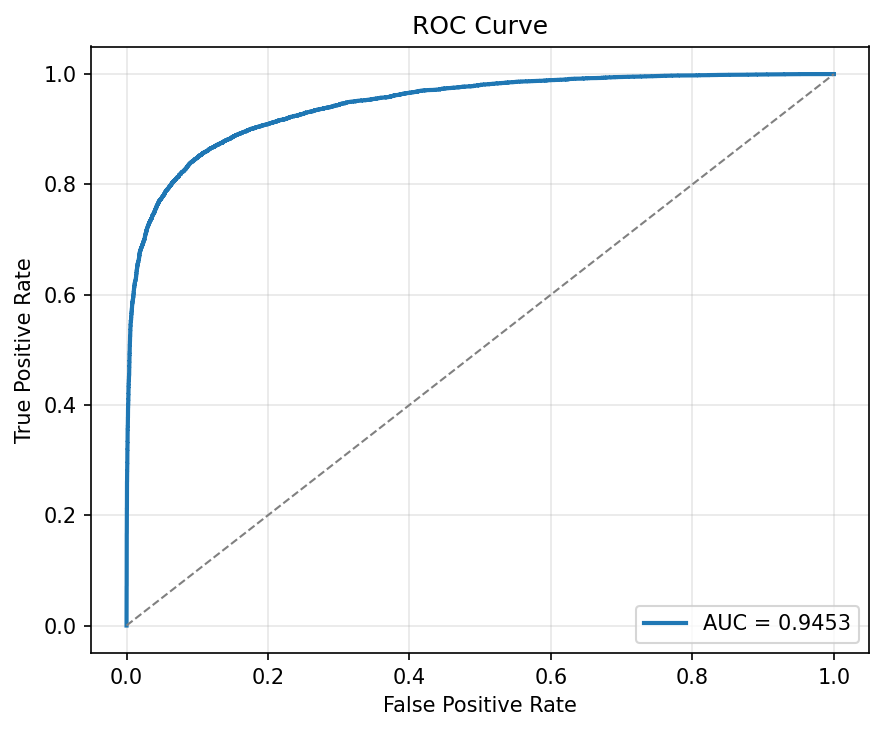


pr_curve.png


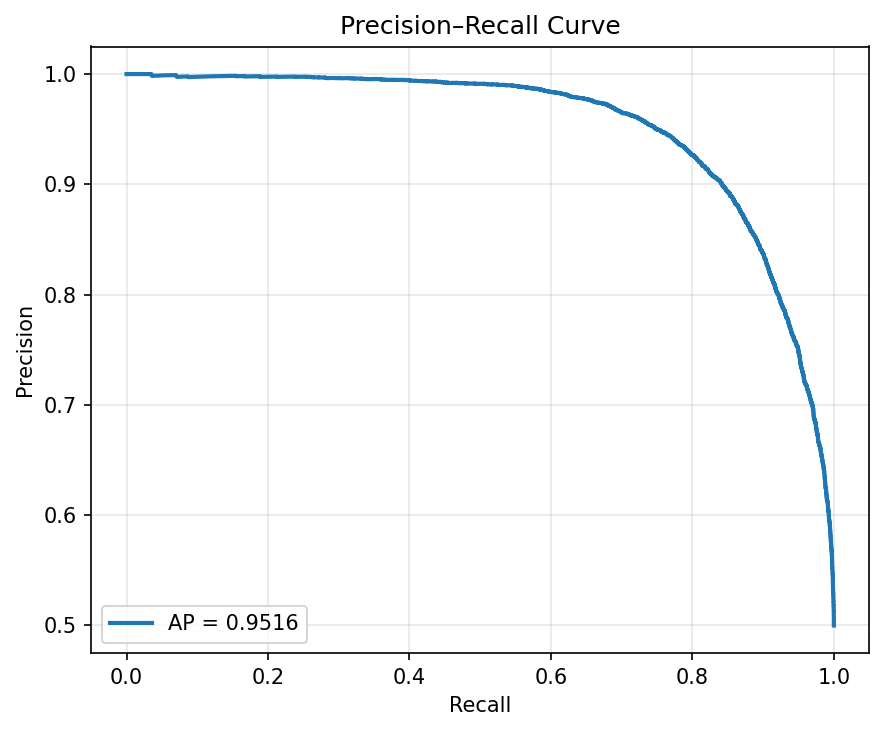


confusion_matrix.png


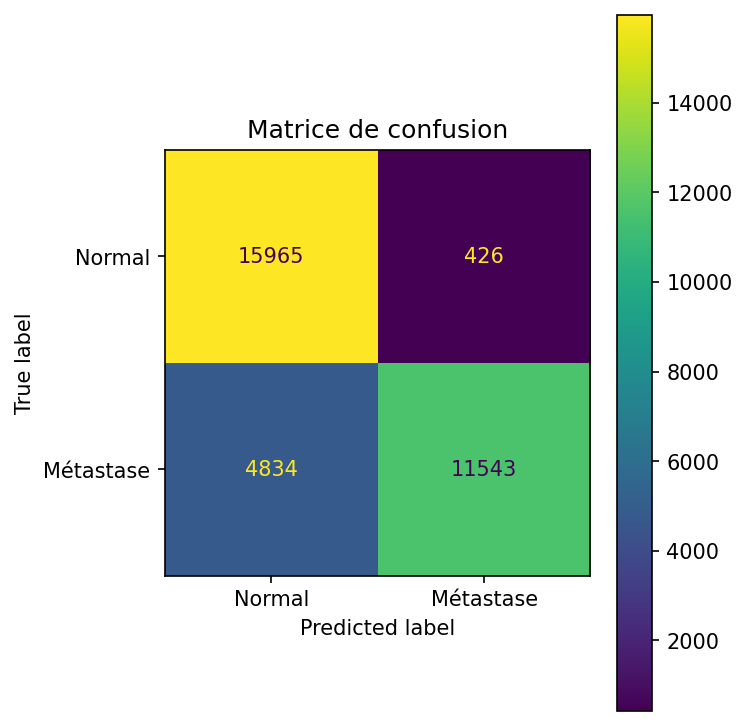

In [10]:
from IPython.display import display, Image as IPImage

for fig_name in ['roc_curve.png', 'pr_curve.png', 'confusion_matrix.png']:
    fig_path = paths.figures_dir / fig_name
    if fig_path.exists():
        print(f'\n{fig_name}')
        display(IPImage(filename=str(fig_path)))

---
**Prochain notebook** : `04_inference.ipynb` pour des prédictions individuelles et Grad-CAM.